<div style="width:100%; background-color:181818; color:f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">

  <img src="https://media1.giphy.com/media/v1.Y2lkPTc5MGI3NjExbG04Y2Jycmk0aHpoaWV1cHZwbDc0M2l1em83MGJqYmd0YjB4cnhsdiZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/eWdS9hpdeccG4/giphy.gif" alt="Beam Oscillation" width="400" style="border-radius:10px;">

  <h3 style="color:ffffff; margin-top:15px;"><b>Data Base Generator of Finite Difference Method of 2D acoustic wave equation, in heterogneus medium</b></h3>

  <p><b>Author:</b> <a href="http://caceli.net/" style="color:3ea6ff; text-decoration:none;">Msc. Ing. Carlos Andrés Celi Sánchez</a></p>
  <p><b>Project:</b> H5 Database Generator</p>
    <h5><b>Simulation and data base creation</b></h5>
  <p><b>Year:</b> JUL - 2026</p>

</div>

### Libraries

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time as tm
import h5py
import pyvista as pv

print("numpy =", np.__version__)
print("matplotlib =", matplotlib.__version__)

numpy = 1.26.4
matplotlib = 3.8.4


In [2]:
import sys
print("Kernel Python:", sys.executable)

Kernel Python: C:\Users\Normando\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe


In [3]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter
from IPython.display import display
from matplotlib.animation import FFMpegWriter
import os
from pathlib import Path
import time as tm

In [5]:
from core import *

In [6]:
# Add project root to sys.path
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

### Paths

In [7]:
h5_path = project_root / "data" / "raw" / "dataset_surface_seismograms.h5"
pyvista_h5_path = project_root / "data" / "raw" / "dataset_pyvista_wavefield_snapshots.h5"

### Initial data:

In [8]:
nx = 400
nz = 400
nt = 1500
xmax = 4000
esp = 0.2 # CFL control
c0 = 3000.0
isx = nx // 2
isz = nz // 4
ist = 100
f0 = 100.0
isnap = 10
nop = 5
fsc = 6.0
idisp = 10
anim = 0
# norder = 2

n_samples = 10

velocityModel  = 0

#--------------------------------------------------------
source_mode = "single"   # "single" for one-pulse source or "rupture_3" for the fixed three-event rupture
#--------------------------------------------------------

save_pyvista_snapshots_h5 = False

# ---------------- Dense surface receiver bank ----------------
receiver_margin = 20
receiver_step = 4
receiver_depth = 10

irx = np.arange(receiver_margin, nx - receiver_margin, receiver_step, dtype=int)
irz = np.full_like(irx, receiver_depth, dtype=int)

print(f"Number of receivers = {len(irx)}")
print(f"Receiver x range    = {irx[0]} to {irx[-1]}")
print(f"Receiver depth iz   = {receiver_depth}")

Number of receivers = 90
Receiver x range    = 20 to 376
Receiver depth iz   = 10


#### Velocity model

In [9]:
if velocityModel == 1:
    vmg = VelocityModel2DGenerator(
        nx=nx,
        nz=nz,
        background_velocity=c0,
        seed=45,
    )

    model_type = "gaussian_anomaly"
else:
    vmg = LayeredVelocityModel2DGenerator(
    nx=nx,
    nz=nz,
    background_velocity=1500.0,
    seed=45,
    )

    model_type = "layered_random"

#### Derived numerical parameters

In [10]:
dx = xmax / (nx - 1)
dz = dx
dt = esp * dx / c0

print("\n" + "=" * 120)
print("Grid increment =", dx)
print("Time Step =", dt, "s")
print("\n" + "=" * 120)

waveLen = c0 / f0
DivWave = waveLen / dx

print("\n" + "=" * 120)
print("Wave Length =", waveLen, "m")
print("Number of finite points per Wave Length =", DivWave)
print("\n" + "=" * 120)


Grid increment = 10.025062656641603
Time Step = 0.0006683375104427735 s


Wave Length = 30.0 m
Number of finite points per Wave Length = 2.9925



#### Source time function


Source mode: single pulse



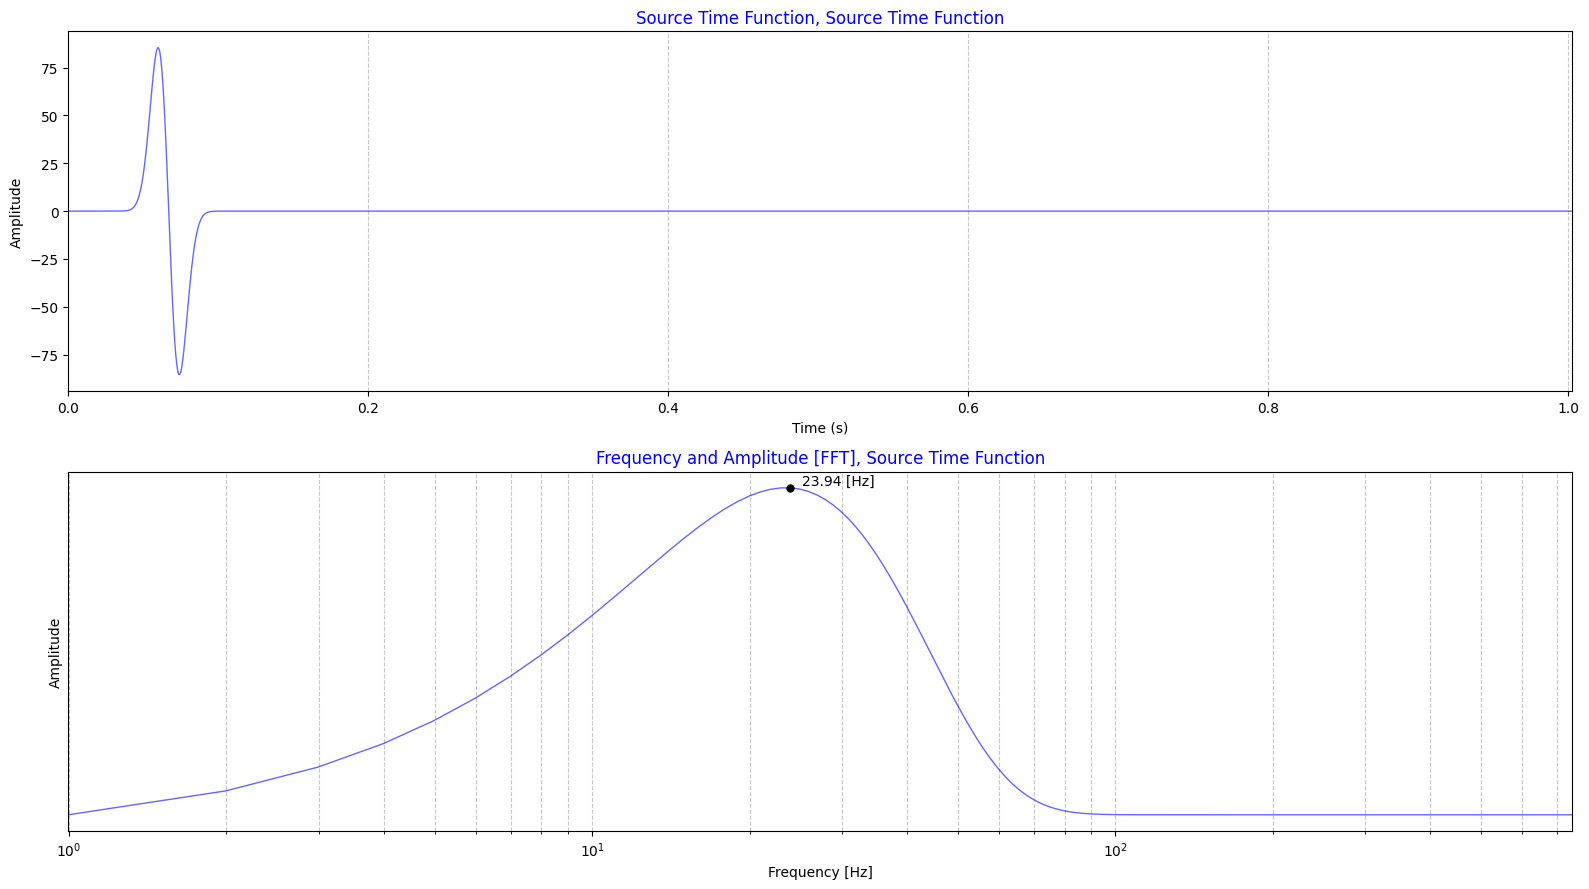

In [11]:
time = np.arange(nt) * dt
src = np.exp(-1.0 / (1.0 / f0**2) * ((time - ist * dt) ** 2))
src = np.gradient(src, dt)

#--------------------------------------------------------
if source_mode == "single":                                             # Use the original one-pulse source mode when selected by the user
    source_events = None                                                # Keep animation2D_FDM in its legacy single-source behavior
    print("\n" + "=" * 120)
    print("Source mode: single pulse")                                  # Print the selected source mode for verification
    print("\n" + "=" * 120)
elif source_mode == "rupture_3":                                        # Use the fixed three-event rupture mode when selected by the user
    rupture_source_x = int(isx)                                         # Keep the rupture events aligned along the same x position
    rupture_source_z = np.array([isz - 40, isz, isz + 40], dtype=int)   # Place three rupture events at different z positions
    rupture_delay_s = np.array([0.000, 0.030, 0.060], dtype=float)      # Trigger each rupture event at a different time delay
    rupture_amplitude = np.array([0.10, 0.55, 0.35], dtype=float)       # Use a nucleation-main-tail amplitude pattern with total amplitude equal to one
    rupture_polarity = np.array([1.0, 1.0, 1.0], dtype=float)           # Keep polarity configurable while using positive polarity for the first rupture version
    rupture_frequency_scale = np.array([0.6, 1.00, 1.30], dtype=float) # Give each rupture event a slightly different source frequency content
    rupture_sources = [                                                 # Build event-specific source wavelets with small waveform differences
        np.gradient(                                                    # Differentiate the Gaussian-like source wavelet as in the original source definition
            np.exp(-1.0 / (1.0 / (f0 * rupture_frequency_scale[event_id])**2) * ((time - ist * dt) ** 2)), # Build one event wavelet with scaled dominant frequency
            dt,                                                         # Use the same time step as the original source derivative
        )                                                               # Finish one differentiated event source wavelet
        for event_id in range(3)                                        # Create one source wavelet for each rupture event
    ]                                                                   # Finish the event-specific source wavelet list
    source_events = [                                                   # Build the fixed multi-source rupture definition used by every sample
        {                                                               # Start one rupture event dictionary
            "x": rupture_source_x,                                      # Use the shared x position for this rupture event
            "z": int(rupture_source_z[event_id]),                       # Use the event-specific z position
            "src": rupture_sources[event_id],                           # Use the event-specific source wavelet instead of copying the same source three times
            "delay_s": float(rupture_delay_s[event_id]),                # Use the event-specific activation delay in seconds
            "amplitude": float(rupture_amplitude[event_id]),            # Use the event-specific amplitude weight
            "polarity": float(rupture_polarity[event_id]),              # Use the event-specific polarity multiplier
        }                                                               # End one rupture event dictionary
        for event_id in range(3)                                        # Create exactly three fixed rupture events
    ]                                                                   # Finish the fixed multi-source rupture list
    print("\n" + "=" * 120)
    print("Source mode: fixed three-event rupture")                     # Print the selected source mode for verification
    print("Fixed rupture source x:", rupture_source_x)                  # Print the shared rupture x position for verification
    print("Fixed rupture source z:", rupture_source_z)                  # Print the rupture z positions for verification
    print("Fixed rupture delays [s]:", rupture_delay_s)                 # Print the rupture delays for verification
    print("Fixed rupture amplitudes:", rupture_amplitude)               # Print the rupture amplitude weights for verification
    print("Fixed rupture frequency scales:", rupture_frequency_scale)   # Print the event source frequency scales for verification
    print("\n" + "=" * 120)
else:                                                                   # Stop when the selected source mode is unknown
    raise ValueError("source_mode must be 'single' or 'rupture_3'.")    # Keep source-mode configuration explicit and safe
#--------------------------------------------------------

# Optional FFT inspection of source
fft_src_obj = FFt_src(src=src, dt=dt, nt=nt, record="Source Time Function")
frequencies, fft_values, fft_table = fft_src_obj.fft_src()

#### Simulation

In [12]:
writer = HDF5SurfaceSeismogramWriter(h5_path=h5_path)

t_start = tm.time()

for i in range(n_samples):
    if velocityModel == 1:
        c, sample_metadata = vmg.random_gaussian_anomaly(
            x_frac_range=(0.10, 0.90),
            z_frac_range=(0.10, 0.90),
            radius_x_range=(45.0, 75.0),
            radius_z_range=(45.0, 75.0),
            contrast_range=(-1500, 1000),
            clip_min_velocity=0.0,
        )
    else:
        c, sample_metadata = vmg.random_layered_model(
            n_layers_range=(4, 8),
            surface_velocity_range=(1500.0, 2200.0),
            velocity_step_range=(250.0, 650.0),
            max_velocity=4500.0,
            interface_roughness_frac_range=(0.015, 0.060),
            fault_probability=0.35,
            clip_min_velocity=300.0,
        )


    anim2d_FDM = animation2D_FDM(
        sample=i+1,
        nx=nx, nz=nz, dx=dx, dz=dz, dt=dt, nt=nt,
        model_type=model_type,
        c=c,
        isx=isx, isz=isz,
        irx=irx, irz=irz,
        src=src,
        #--------------------------------------------------------
        source_events=source_events,              # Use the selected source mode without changing the training target shape
        #--------------------------------------------------------
        idisp=idisp,
        nop=nop,
        fsc=fsc,
        cmap='gray',
        show=bool(anim),
        save=False,
        video_name=None,
        fps=10,
        dpi=120,
        bitrate=1800,
        sample_metadata=sample_metadata,
        # Optional PyVista snapshot output
        # store_snapshots=True,
        store_snapshots=save_pyvista_snapshots_h5,
        snapshot_interval=5,
        snapshot_h5_path=pyvista_h5_path,
        save_snapshots_to_h5=save_pyvista_snapshots_h5,
    )

    if save_pyvista_snapshots_h5 == True:
        results, snapshots = anim2d_FDM.animate()
    else:
        results = anim2d_FDM.animate()
    
    writer.append_sample(results)

    print(f"Sample {i+1}/{n_samples} saved. Current total = {writer.count_samples()}")

t_end = tm.time()
elapsed_time = t_end - t_start
print("\n" + "=" * 90)
print('\033[1;32m Total computation time : \033[0m\n')
print("=" * 90)
print(f"\033[1;36mComputation Time in seconds = {elapsed_time:.2f}\033[0m")
print(f"\033[1;36mComputation Time in minutes = {elapsed_time/60:.2f}\033[0m")
print(f"\033[1;36mComputation Time in hours = {elapsed_time/3600:.3f}\033[0m")

Courant-Friedrichs-Lewy criterion (CFL) :
0.3
Sample 1/10 saved. Current total = 1
Courant-Friedrichs-Lewy criterion (CFL) :
0.26667302340957294
Sample 2/10 saved. Current total = 2
Courant-Friedrichs-Lewy criterion (CFL) :
0.23923546244856123
Sample 3/10 saved. Current total = 3
Courant-Friedrichs-Lewy criterion (CFL) :
0.2827907758281372
Sample 4/10 saved. Current total = 4
Courant-Friedrichs-Lewy criterion (CFL) :
0.26888886637737824
Sample 5/10 saved. Current total = 5
Courant-Friedrichs-Lewy criterion (CFL) :
0.20435875440480386
Sample 6/10 saved. Current total = 6
Courant-Friedrichs-Lewy criterion (CFL) :
0.2840945483641588
Sample 7/10 saved. Current total = 7
Courant-Friedrichs-Lewy criterion (CFL) :
0.2763552574315031
Sample 8/10 saved. Current total = 8
Courant-Friedrichs-Lewy criterion (CFL) :
0.3
Sample 9/10 saved. Current total = 9
Courant-Friedrichs-Lewy criterion (CFL) :
0.3
Sample 10/10 saved. Current total = 10

 Total computation time : 

Computation Time in seconds = 

#### Quick check of returned results

In [13]:
print("\nReturned keys:")
print(results.keys())

print("\nVelocity model shape:", results["velocity_model"].shape)
print("Surface seismograms shape:", results["surface_seismograms"].shape)
print("Receiver x:", results["receiver_x"])
print("Receiver z:", results["receiver_z"])


Returned keys:
dict_keys(['velocity_model', 'surface_seismograms', 'dx', 'dz', 'dt', 'nx', 'nz', 'nt', 'source_x', 'source_z', 'source_x_all', 'source_z_all', 'source_delay_s', 'source_delay_samples', 'source_amplitude', 'source_polarity', 'n_source_events', 'receiver_x', 'receiver_z', 'model_type', 'sample_metadata', 'CFL'])

Velocity model shape: (400, 400)
Surface seismograms shape: (90, 1500)
Receiver x: [ 20  24  28  32  36  40  44  48  52  56  60  64  68  72  76  80  84  88
  92  96 100 104 108 112 116 120 124 128 132 136 140 144 148 152 156 160
 164 168 172 176 180 184 188 192 196 200 204 208 212 216 220 224 228 232
 236 240 244 248 252 256 260 264 268 272 276 280 284 288 292 296 300 304
 308 312 316 320 324 328 332 336 340 344 348 352 356 360 364 368 372 376]
Receiver z: [10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10

In [14]:
print("\nHDF5 file saved at:")
print(h5_path)

print("\nFinal number of samples in HDF5:")
print(writer.count_samples())


HDF5 file saved at:
C:\Dropbox\Root\Github Repositories\Neural-Surrogate-for-Surface-Seismogram-\data\raw\dataset_surface_seismograms.h5

Final number of samples in HDF5:
10


### SPLIT DATASET INTO TRAINING AND TEST SETS

* HDF5 file path

In [15]:
h5_path = project_root / "data" / "raw" / "dataset_surface_seismograms.h5"
print("HDF5 file path:")
print(h5_path)

if not h5_path.exists():
    raise FileNotFoundError(f"HDF5 file not found: {h5_path}")

HDF5 file path:
C:\Dropbox\Root\Github Repositories\Neural-Surrogate-for-Surface-Seismogram-\data\raw\dataset_surface_seismograms.h5


* Split Dataset into training, validation and test sets

In [16]:
# ---------------- Read number of samples ----------------
with h5py.File(h5_path, "r") as h5f:
    n_samples = h5f["inputs/velocity_model"].shape[0]

print(f"Total number of samples = {n_samples}")

# ---------------- Reproducible random split ----------------
seed_split = 10
rng = np.random.default_rng(seed_split)

all_ids = np.arange(n_samples, dtype=int)
rng.shuffle(all_ids)
print(rng)

# ---------------- Split proportions ----------------
train_ratio = 0.70
val_ratio   = 0.15
test_ratio  = 0.15

n_train = int(round(train_ratio * n_samples))
n_val   = int(round(val_ratio * n_samples))
n_test  = n_samples - n_train - n_val

train_ids = np.sort(all_ids[:n_train])
val_ids   = np.sort(all_ids[n_train:n_train + n_val])
test_ids  = np.sort(all_ids[n_train + n_val:])

# ---------------- Write splits into HDF5 ----------------
writer = HDF5SurfaceSeismogramWriter(h5_path=h5_path)
writer.write_splits(train_ids=train_ids, val_ids=val_ids, test_ids=test_ids)

print("\nSplits successfully written into HDF5.")

# ---------------- Verify saved splits ----------------
with h5py.File(h5_path, "r") as h5f:
    print("Top-level keys:")
    print(list(h5f.keys()))

    print("\nKeys inside 'splits':")
    print(list(h5f["splits"].keys()))
    train_ids_check = h5f["splits/train_ids"][:]
    val_ids_check   = h5f["splits/val_ids"][:]
    test_ids_check  = h5f["splits/test_ids"][:]

print("\nSplit sizes:")
print(f"Train = {len(train_ids)}")
print(f"Val   = {len(val_ids)}")
print(f"Test  = {len(test_ids)}")


print("\nVerification from HDF5:")
print("train_ids =", train_ids_check)
print("val_ids   =", val_ids_check)
print("test_ids  =", test_ids_check)

Total number of samples = 10
Generator(PCG64)

Splits successfully written into HDF5.
Top-level keys:
['inputs', 'metadata', 'outputs', 'splits']

Keys inside 'splits':
['test_ids', 'train_ids', 'val_ids']

Split sizes:
Train = 7
Val   = 2
Test  = 1

Verification from HDF5:
train_ids = [1 2 3 4 5 7 9]
val_ids   = [0 6]
test_ids  = [8]
